In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models, EfficientFrontier, plotting

tickers = ["TSLA", "BND", "SPY"]
prices = pd.DataFrame({
    t: pd.read_csv(f"../data/processed/{t}.csv", index_col="Date", parse_dates=True)["Close"]
    for t in tickers
})
prices = prices.asfreq("B").ffill()

# Use TSLA's forecasted expected return (from Task 3) blended with BND/SPY historical means
mu = expected_returns.mean_historical_return(prices)
# Optional: override TSLA's expected return with the forward forecast's implied annual return
# mu["TSLA"] = (forecast_mean.iloc[-1] / tsla["Close"].iloc[-1]) - 1

S = risk_models.sample_cov(prices)

ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe(risk_free_rate=0.02)
cleaned_weights = ef.clean_weights()
print("Optimal Weights (Max Sharpe):", cleaned_weights)

performance = ef.portfolio_performance(verbose=True, risk_free_rate=0.02)

Optimal Weights (Max Sharpe): OrderedDict([('TSLA', 0.15379), ('BND', 0.0), ('SPY', 0.84621)])
Expected annual return: 16.2%
Annual volatility: 20.4%
Sharpe Ratio: 0.70


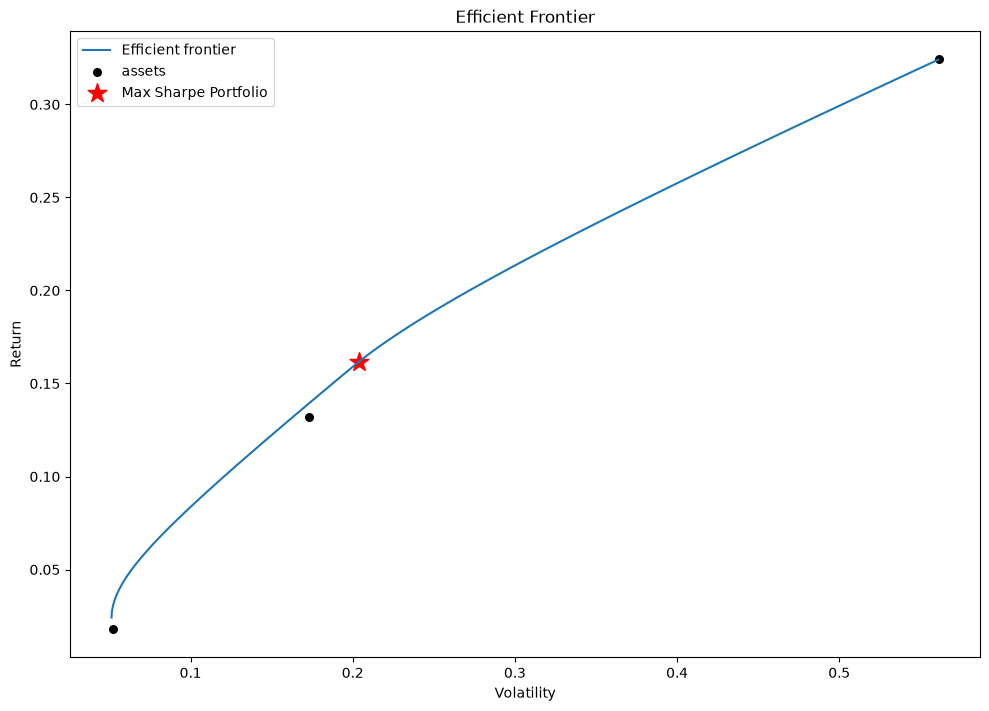

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
ef_plot = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

ret_tangent, std_tangent, _ = performance
ax.scatter(std_tangent, ret_tangent, marker="*", s=200, color="red", label="Max Sharpe Portfolio")
ax.legend()
plt.title("Efficient Frontier")
plt.savefig("../data/processed/efficient_frontier.png", dpi=150)
plt.show()

In [7]:
ef_minvol = EfficientFrontier(mu, S)
minvol_weights = ef_minvol.min_volatility()
print("Min Volatility Weights:", ef_minvol.clean_weights())
ef_minvol.portfolio_performance(verbose=True, risk_free_rate=0.02)

Min Volatility Weights: OrderedDict([('TSLA', 0.0), ('BND', 0.9454), ('SPY', 0.0546)])
Expected annual return: 2.4%
Annual volatility: 5.1%
Sharpe Ratio: 0.08


(np.float64(0.02425093686312484),
 np.float64(0.05127627018147889),
 np.float64(0.08290261456380826))